In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.special import inv_boxcox

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('CIS2022_PUMF_renamed.csv')
print(f"Raw dataset shape: {df.shape}")
df.head()

Raw dataset shape: (96302, 210)


,Reference year,Household identifier,Person identifier,Final weight,Province,Adjusted size of area of residence,Market Basket Measure (MBM) Region,Person's age group as of December 31 of refyear,Sex,Marital status,Flag - Person completed high school,"Highest level of education of person, 2nd grouping","Flag - Attended school, college, CEGEP or university during refyear",Full-time or part-time student during refyear,Flag - Person was employed during the reference year,Yearly summary of time worked during the refyear,Annual labour force status,Number of weeks employed during refyear,Number of weeks unemployed during refyear,Number of weeks not in the labour force during refyear,Average usual hours worked per week at all jobs during refyear,Total usual hours worked at all jobs during refyear,Flag - Person was a paid employee during refyear,Flag - Person was self-employed during refyear,Flag - Person is a landed immigrant,...,Household composition,Flag - Major income earner in the household,Gap ratio - LICO-AT,Flag - After-tax income below LICO-AT,Gap ratio - LICO-BT,Flag - Before-tax income below LICO-BT,Gap ratio - LIM-AT,Flag - After-tax income below the LIM-AT threshold,Gap ratio - MBM (2018 base),Flag - Disposable income below MBM threshold (2018 base),Type of dwelling,Ownership of dwelling,Condition of dwelling,"Flag - Dwelling suitable, according to Nat. Occ. Standard",Flag - Mortgage on dwelling,"Monthly mortgage payment, excluding property taxes, for the household",Monthly condominium fee,Monthly rent paid for the household,"Flag - Rent subsidized by government, employer or relative",Core housing need indicator,Food security - adult status (including marginally),Food security - child status (including marginally),Food security - household status (including marginally),Flag - Visible minority status,Date of file creation
0,2022,2129,212901,88.3160,35,6,19,11,1,1,1,3,6,6,2,30,3,0,0,52,999.6,9996,6,6,2,...,2,2,999.6,2,999.6,2,999.6,2,999.6,2,1,1,3,1,2,99999996,99999996,99999996,6,2,0,6,0,2,17DEC2024
1,2022,2129,212902,88.3160,35,6,19,11,2,1,1,3,6,6,1,21,5,13,0,39,37.5,488,1,2,2,...,2,1,999.6,2,999.6,2,999.6,2,999.6,2,1,1,3,1,2,99999996,99999996,99999996,6,2,0,6,0,2,17DEC2024
2,2022,2130,213001,63.1092,13,6,9,9,2,99,1,4,2,6,1,11,1,52,0,0,40.0,2080,1,2,2,...,2,1,999.6,2,999.6,2,999.6,2,999.6,2,1,1,3,1,1,1100,99999996,99999996,6,2,0,0,0,2,17DEC2024
3,2022,2130,213002,63.1092,13,6,9,3,1,96,6,6,6,6,6,96,96,96,96,96,999.6,9996,6,6,6,...,2,2,999.6,2,999.6,2,999.6,2,999.6,2,1,1,3,1,1,1100,99999996,99999996,6,2,0,0,0,2,17DEC2024
4,2022,2131,213101,76.0554,35,6,19,10,2,1,1,3,2,6,1,11,1,52,0,0,35.0,1820,1,2,2,...,2,2,999.6,2,999.6,2,999.6,2,999.6,2,1,1,3,1,1,2200,99999996,99999996,6,2,0,6,0,2,17DEC2024


In [3]:
TARGET = 'After-tax income'

# --- Drop ID / metadata columns ---
drop_cols = [
    'Reference year', 'Household identifier', 'Person identifier',
    'Final weight', 'Economic family identifier', 'Census family identifier',
    'Date of file creation'
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

# --- Drop rows where target is "Valid skip" (999999999996) ---
print(f"Rows before dropping target skips: {len(df)}")
df = df[df[TARGET] != 999999999996].copy()
print(f"Rows after dropping target skips:  {len(df)}")

# --- Replace skip codes with NaN per-column based on data dictionary ---
# Pattern from data dictionary:
#   12-digit dollar columns: 999999999996 = valid skip
#   2-digit categorical columns: 96 = valid skip, 99 = not stated
#   1-digit flag columns: 6 = valid skip, 9 = not stated
#   USHRWK (5.1 length): 999.6 = valid skip
#   ALHRWK (4-digit): 9996 = valid skip

# Columns with NO skip codes (universe = "All persons", no restrictions)
no_skip_cols = {
    'Province', 'Adjusted size of area of residence',
    'Market Basket Measure (MBM) Region',
    "Person's age group as of December 31 of refyear", 'Sex',
    'Number of economic family members', 'Economic family type',
    'Number of census family members', 'Census family composition',
    'Number of household members', 'Household composition',
    'Type of dwelling', 'Ownership of dwelling', 'Condition of dwelling'
}

# 12-digit dollar amount columns: skip = 999999999996
for col in df.columns:
    if col == TARGET or col in no_skip_cols:
        continue
    if df[col].dtype in ['int64', 'float64']:
        count_sentinel = (df[col] == 999999999996).sum()
        if count_sentinel > 0:
            df[col] = df[col].replace(999999999996, np.nan)

# 2-digit categorical columns with skip=96, not-stated=99
two_digit_skip_cols = [
    'Marital status', 'Yearly summary of time worked during the refyear',
    'Annual labour force status',
    'Number of weeks employed during refyear',
    'Number of weeks unemployed during refyear',
    'Number of weeks not in the labour force during refyear',
    'Age group of oldest person in economic family',
    'Age group of youngest person in economic family',
    'Major source of income for the economic family',
    'Age group of oldest person in census family',
    'Age group of youngest person in census family',
    'Major source of income for the census family',
    'Major source of income',
    'Core housing need indicator',
    'Food security - adult status (including marginally)',
    'Food security - child status (including marginally)',
    'Food security - household status (including marginally)',
]
for col in two_digit_skip_cols:
    if col in df.columns:
        df[col] = df[col].replace({96: np.nan, 99: np.nan})

# 1-digit flag columns with skip=6, not-stated=9
one_digit_skip_cols = [
    'Flag - Person completed high school',
    'Highest level of education of person, 2nd grouping',
    'Flag - Attended school, college, CEGEP or university during refyear',
    'Full-time or part-time student during refyear',
    'Flag - Person was employed during the reference year',
    'Flag - Person was a paid employee during refyear',
    'Flag - Person was self-employed during refyear',
    'Flag - Person is a landed immigrant',
    'Number of years since person immigrated to Canada, grouping',
    'Flag - Major income earner in the economic family',
    'Flag - Economic family includes major income earner of household',
    'Relationship to major income earner in economic family, group',
    'Flag - Major income earner in the census family',
    'Flag - Census family includes major income earner of household',
    'Relationship to major income earner in census family, group',
    'Flag - Major income earner in the household',
    'Flag - Dwelling suitable, according to Nat. Occ. Standard',
    'Flag - Mortgage on dwelling',
    'Flag - Rent subsidized by government, employer or relative',
    'Flag - Visible minority status',
]
for col in one_digit_skip_cols:
    if col in df.columns:
        df[col] = df[col].replace({6: np.nan, 9: np.nan})

# Special cases
if 'Average usual hours worked per week at all jobs during refyear' in df.columns:
    df['Average usual hours worked per week at all jobs during refyear'] = \
        df['Average usual hours worked per week at all jobs during refyear'].replace(999.6, np.nan)

if 'Total usual hours worked at all jobs during refyear' in df.columns:
    df['Total usual hours worked at all jobs during refyear'] = \
        df['Total usual hours worked at all jobs during refyear'].replace(9996, np.nan)

# Monthly mortgage/condo/rent: skip codes based on data dictionary
if 'Monthly mortgage payment, excluding property taxes, for the household' in df.columns:
    df['Monthly mortgage payment, excluding property taxes, for the household'] = \
        df['Monthly mortgage payment, excluding property taxes, for the household'].replace(999999999996, np.nan)
if 'Monthly condominium fee' in df.columns:
    df['Monthly condominium fee'] = df['Monthly condominium fee'].replace(999999999996, np.nan)
if 'Monthly rent paid for the household' in df.columns:
    df['Monthly rent paid for the household'] = df['Monthly rent paid for the household'].replace(999999999996, np.nan)

# Drop non-numeric columns
df = df.select_dtypes(include=[np.number])

print(f"\nCleaned dataset shape: {df.shape}")
print(f"NaN counts (top 20):")
print(df.isnull().sum().sort_values(ascending=False).head(20))

Rows before dropping target skips: 96302
Rows after dropping target skips:  81163

Cleaned dataset shape: (81163, 203)
NaN counts (top 20):
Full-time or part-time student during refyear                          72602
Number of years since person immigrated to Canada, grouping            67403
Flag - Rent subsidized by government, employer or relative             67393
Flag - Attended school, college, CEGEP or university during refyear    44606
Flag - Person was a paid employee during refyear                       30411
Total usual hours worked at all jobs during refyear                    30411
Average usual hours worked per week at all jobs during refyear         30411
Flag - Person was self-employed during refyear                         30411
Annual labour force status                                             18841
Number of weeks unemployed during refyear                              18841
Number of weeks employed during refyear                                18841
Number of wee

In [4]:
# --- Prepare features and target ---
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Impute NaNs with median
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

# --- Train/Test Split (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nTarget stats (train):")
print(y_train.describe())

Training set: (64930, 202)
Test set:     (16233, 202)

Target stats (train):
count    6.493000e+04
mean     4.686262e+04
std      4.160734e+04
min     -1.595080e+06
25%      2.187500e+04
50%      3.960250e+04
75%      6.257000e+04
max      9.809900e+05
Name: After-tax income, dtype: float64


## Task 1: Data Balancing — Handling Outliers & Unequal Variance for Regression

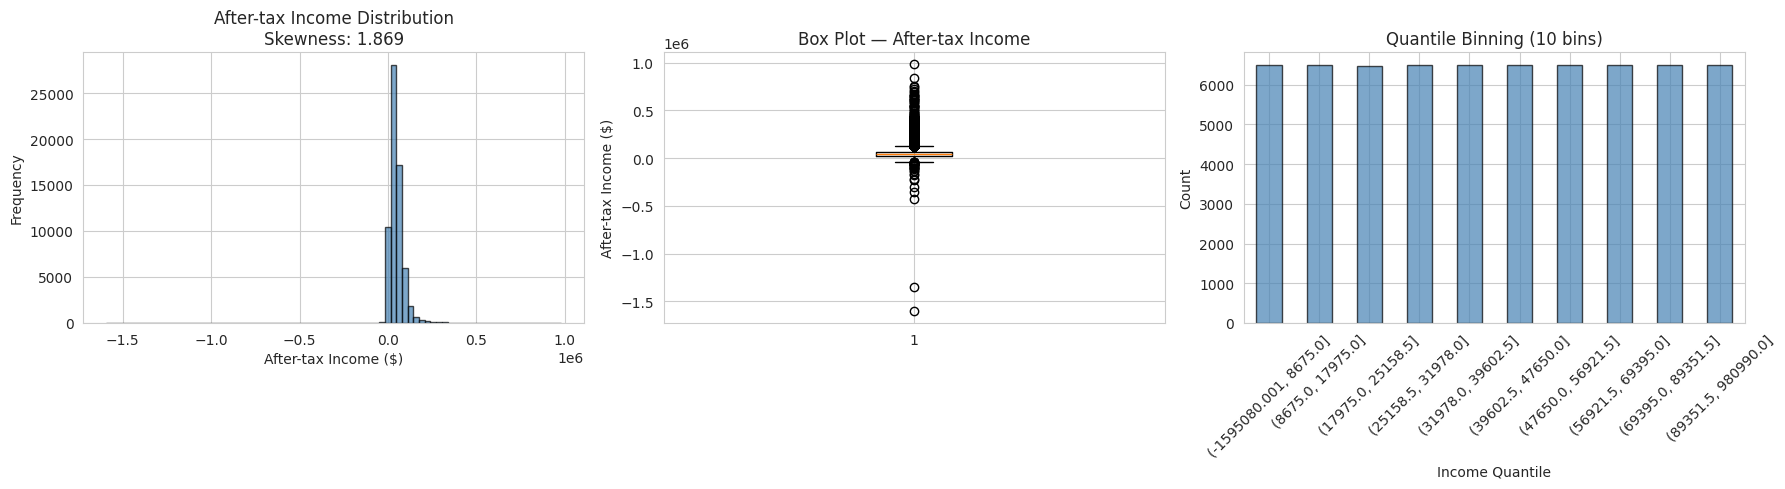

IQR: 40,695
Lower bound: -39,168 | Upper bound: 123,612
Outliers: 2348 (3.6%)
Skewness: 1.869
Kurtosis: 89.353


In [5]:
# --- Identify outliers and imbalance in target ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(y_train, bins=80, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f'After-tax Income Distribution\nSkewness: {y_train.skew():.3f}')
axes[0].set_xlabel('After-tax Income ($)')
axes[0].set_ylabel('Frequency')

# Box plot
axes[1].boxplot(y_train, vert=True)
axes[1].set_title('Box Plot — After-tax Income')
axes[1].set_ylabel('After-tax Income ($)')

# Quantile binning
quantile_bins = pd.qcut(y_train, q=10, duplicates='drop')
bin_counts = quantile_bins.value_counts().sort_index()
bin_counts.plot(kind='bar', ax=axes[2], color='steelblue', edgecolor='black', alpha=0.7)
axes[2].set_title('Quantile Binning (10 bins)')
axes[2].set_xlabel('Income Quantile')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# IQR outlier detection
Q1, Q3 = y_train.quantile(0.25), y_train.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = y_train[(y_train < lower_bound) | (y_train > upper_bound)]
print(f"IQR: {IQR:,.0f}")
print(f"Lower bound: {lower_bound:,.0f} | Upper bound: {upper_bound:,.0f}")
print(f"Outliers: {len(outliers)} ({len(outliers)/len(y_train)*100:.1f}%)")
print(f"Skewness: {y_train.skew():.3f}")
print(f"Kurtosis: {y_train.kurtosis():.3f}")

In [6]:
# --- Apply 4 Transformations on training target ---

# Shift constant to make all values positive (needed for log, sqrt, box-cox)
shift = abs(y_train.min()) + 1
y_train_shifted = y_train + shift
y_test_shifted = y_test + shift

# 1. Log Transformation
y_train_log = np.log1p(y_train_shifted)

# 2. Square-root Transformation
y_train_sqrt = np.sqrt(y_train_shifted)

# 3. Box-Cox Transformation
y_train_boxcox, boxcox_lambda = stats.boxcox(y_train_shifted)
print(f"Box-Cox lambda: {boxcox_lambda:.4f}")

# 4. Robust Scaling
robust_scaler = RobustScaler()
y_train_robust = robust_scaler.fit_transform(y_train.values.reshape(-1, 1)).flatten()

transformations = {
    'Original': y_train,
    'Log': y_train_log,
    'Square-root': y_train_sqrt,
    'Box-Cox': y_train_boxcox,
    'Robust Scaling': y_train_robust
}

Box-Cox lambda: 0.9570


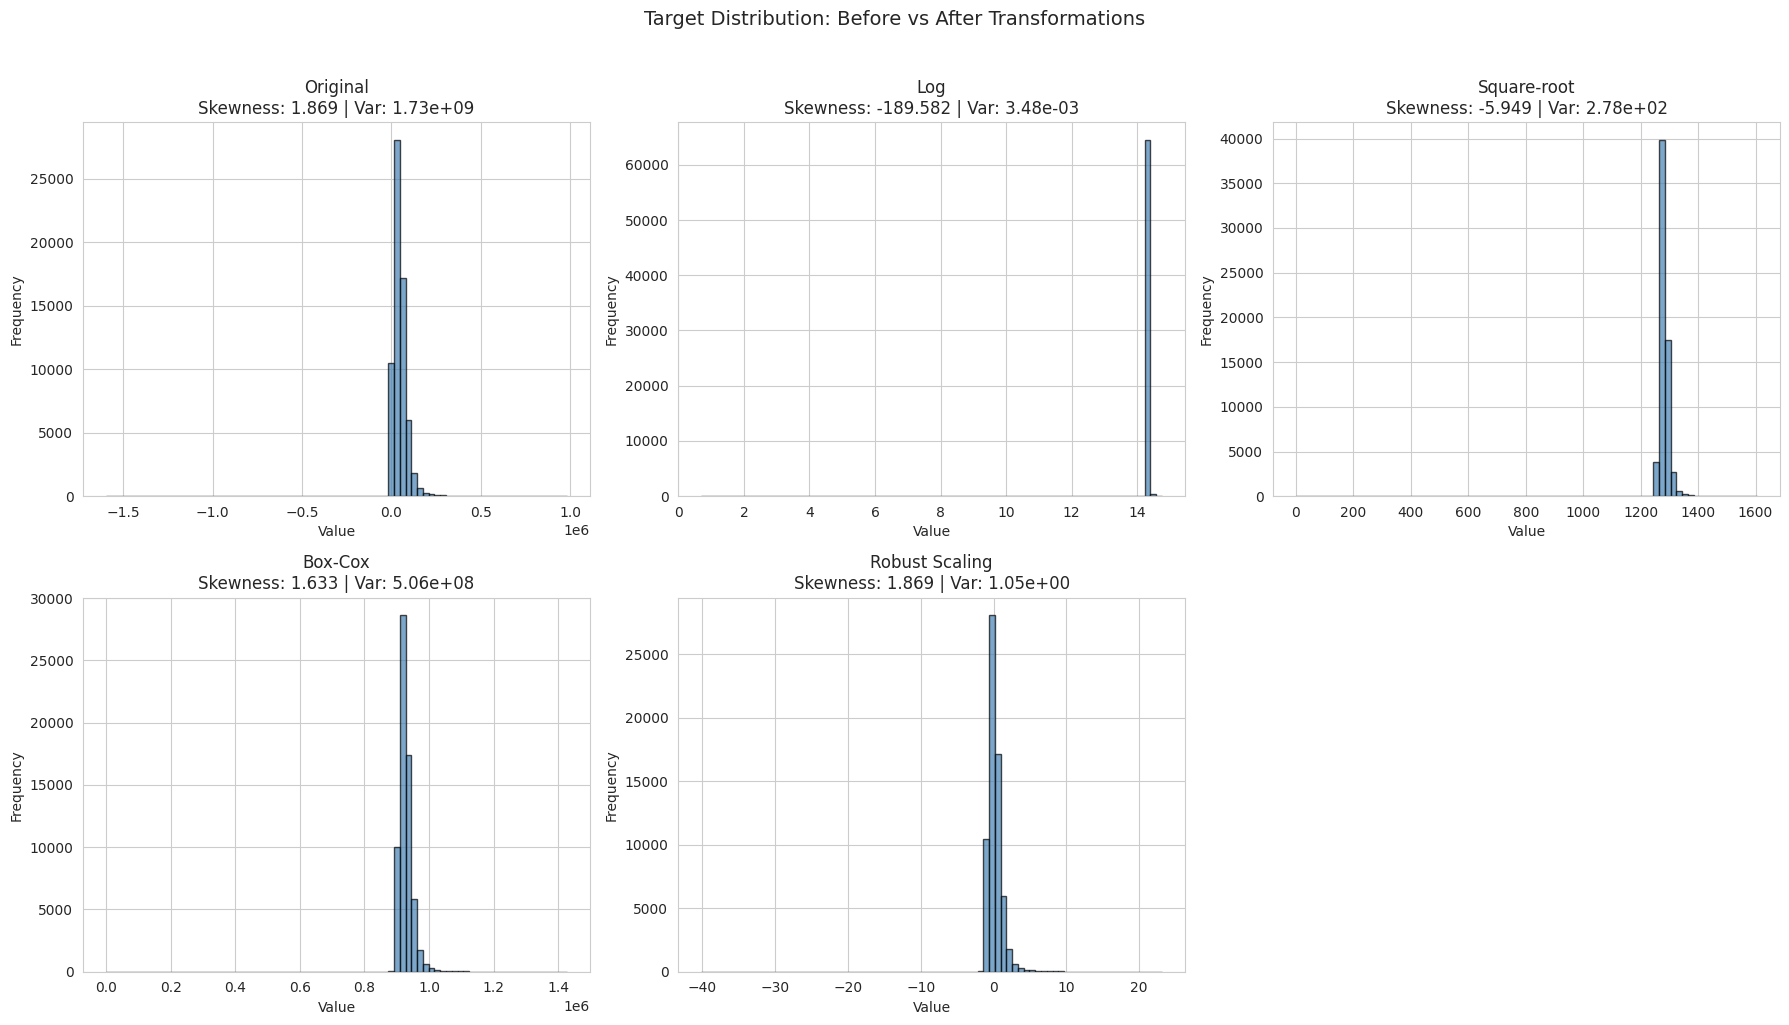

Transformation    Skewness     Variance          Mean          Std
      Original    1.868726 1.731170e+09  46862.621808 41607.337080
           Log -189.582313 3.482416e-03     14.310889     0.059012
   Square-root   -5.949105 2.776405e+02   1281.275140    16.662548
       Box-Cox    1.632644 5.060042e+08 927615.218090 22494.537987
Robust Scaling    1.868726 1.045340e+00      0.178403     1.022419


In [7]:
# --- Before vs After Distribution Plots ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, data) in enumerate(transformations.items()):
    ax = axes[i]
    ax.hist(data, bins=80, color='steelblue', edgecolor='black', alpha=0.7)
    skew_val = pd.Series(data).skew()
    var_val = pd.Series(data).var()
    ax.set_title(f'{name}\nSkewness: {skew_val:.3f} | Var: {var_val:.2e}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

axes[5].axis('off')
plt.suptitle('Target Distribution: Before vs After Transformations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Summary table
summary = pd.DataFrame({
    'Transformation': list(transformations.keys()),
    'Skewness': [pd.Series(d).skew() for d in transformations.values()],
    'Variance': [pd.Series(d).var() for d in transformations.values()],
    'Mean': [pd.Series(d).mean() for d in transformations.values()],
    'Std': [pd.Series(d).std() for d in transformations.values()],
})
print(summary.to_string(index=False))

In [8]:
def mape(y_true, y_pred):
    """Mean Absolute Percentage Error, ignoring zeros in y_true."""
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_model(y_true, y_pred, label=''):
    """Return dict of regression metrics."""
    return {
        'Model': label,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R²': r2_score(y_true, y_pred),
        'MAPE (%)': mape(y_true.values, y_pred)
    }

# --- Baseline: Random Forest on raw (untransformed) target ---
rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train, y_train)
y_pred_baseline = rf_baseline.predict(X_test)

baseline_metrics = evaluate_model(y_test, y_pred_baseline, 'RF — No Transform')
print(pd.DataFrame([baseline_metrics]).to_string(index=False))

            Model        MAE        RMSE       R²  MAPE (%)
RF — No Transform 338.466093 9914.697309 0.945619  0.611562


In [9]:
# --- Train RF with each transformation, inverse-transform, evaluate on original test ---
all_metrics = [baseline_metrics]

# 1. Log Transform
rf_log = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_log.fit(X_train, y_train_log)
y_pred_log_raw = rf_log.predict(X_test)
y_pred_log = np.expm1(y_pred_log_raw) - shift  # inverse: expm1 then un-shift
all_metrics.append(evaluate_model(y_test, y_pred_log, 'RF — Log Transform'))

# 2. Square-root Transform
rf_sqrt = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_sqrt.fit(X_train, y_train_sqrt)
y_pred_sqrt_raw = rf_sqrt.predict(X_test)
y_pred_sqrt = y_pred_sqrt_raw ** 2 - shift  # inverse: square then un-shift
all_metrics.append(evaluate_model(y_test, y_pred_sqrt, 'RF — Sqrt Transform'))

# 3. Box-Cox Transform
rf_boxcox = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_boxcox.fit(X_train, y_train_boxcox)
y_pred_bc_raw = rf_boxcox.predict(X_test)
y_pred_bc = inv_boxcox(y_pred_bc_raw, boxcox_lambda) - shift  # inverse box-cox then un-shift
all_metrics.append(evaluate_model(y_test, y_pred_bc, 'RF — Box-Cox Transform'))

# 4. Robust Scaling
rf_robust = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_robust.fit(X_train, y_train_robust)
y_pred_robust_raw = rf_robust.predict(X_test)
y_pred_robust = robust_scaler.inverse_transform(y_pred_robust_raw.reshape(-1, 1)).flatten()
all_metrics.append(evaluate_model(y_test, y_pred_robust, 'RF — Robust Scaling'))

# --- Comparison table ---
results_df = pd.DataFrame(all_metrics)
print(results_df.to_string(index=False))

                 Model        MAE        RMSE       R²  MAPE (%)
     RF — No Transform 338.466093 9914.697309 0.945619  0.611562
    RF — Log Transform 288.696952 3855.404276 0.991777  0.689516
   RF — Sqrt Transform 299.941100 5558.467453 0.982908  0.673582
RF — Box-Cox Transform 335.423652 9562.771219 0.949411  0.631257
   RF — Robust Scaling 330.807465 9738.980763 0.947529  0.711870


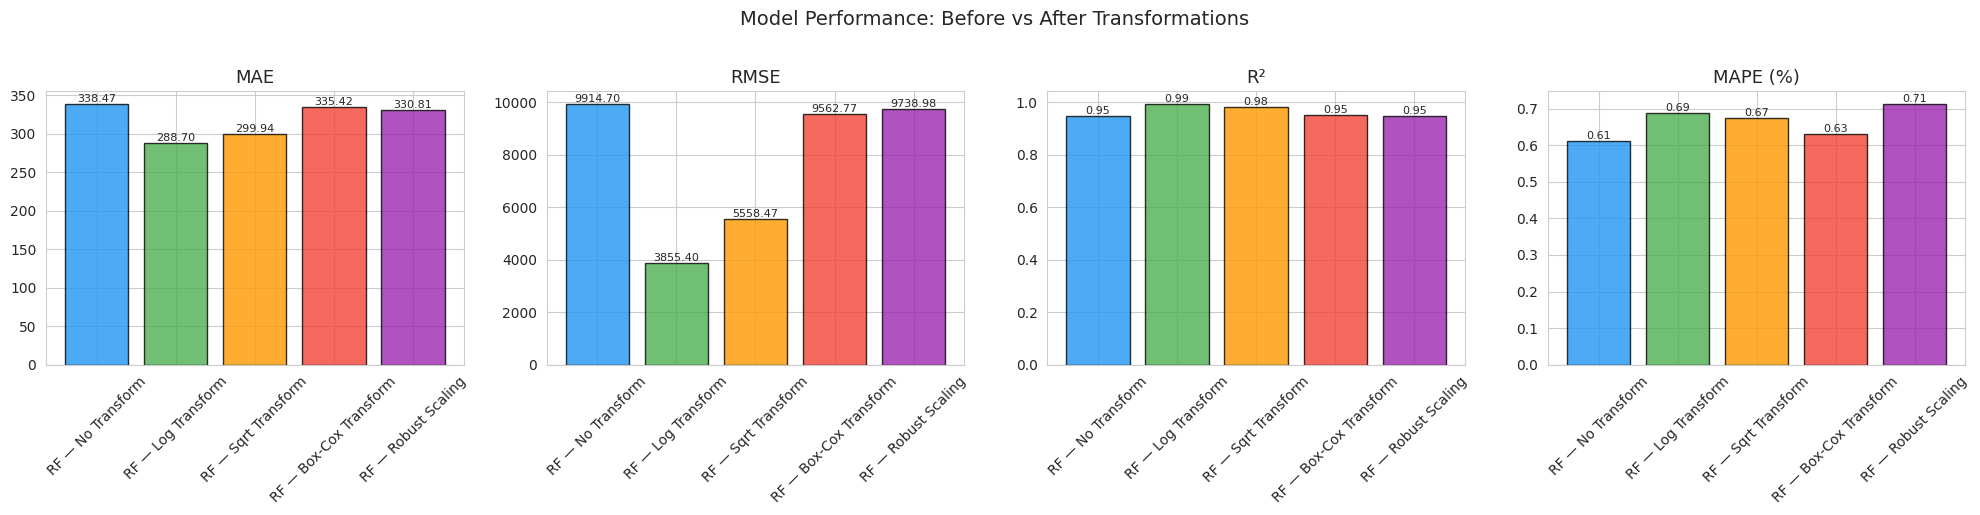

In [10]:
# --- Bar chart comparing metrics across transformations ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics_to_plot = ['MAE', 'RMSE', 'R²', 'MAPE (%)']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336', '#9C27B0']

for i, metric in enumerate(metrics_to_plot):
    bars = axes[i].bar(results_df['Model'], results_df[metric], color=colors, edgecolor='black', alpha=0.8)
    axes[i].set_title(metric, fontsize=13)
    axes[i].tick_params(axis='x', rotation=45)
    for bar, val in zip(bars, results_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f'{val:.2f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Performance: Before vs After Transformations', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Task 2: Hyperparameter Explanation
*See separate explanations document for hyperparameter tables.*

## Task 3: Hyperparameter Tuning (GridSearchCV)

In [11]:
# --- Determine best transformation from Task 1 ---
best_transform = results_df.loc[results_df['R²'].idxmax(), 'Model']
print(f"Best transformation based on R²: {best_transform}")
print("Using the best-performing target for hyperparameter tuning below.")

# Select the training target to use going forward
# (Use raw target if baseline was best, otherwise use the best transform)
if 'No Transform' in best_transform:
    y_train_tuning = y_train
    transform_used = 'none'
elif 'Log' in best_transform:
    y_train_tuning = y_train_log
    transform_used = 'log'
elif 'Sqrt' in best_transform:
    y_train_tuning = y_train_sqrt
    transform_used = 'sqrt'
elif 'Box-Cox' in best_transform:
    y_train_tuning = y_train_boxcox
    transform_used = 'boxcox'
else:
    y_train_tuning = y_train_robust
    transform_used = 'robust'

def inverse_transform_predictions(y_pred_raw, transform_type):
    """Inverse-transform predictions back to original scale."""
    if transform_type == 'none':
        return y_pred_raw
    elif transform_type == 'log':
        return np.expm1(y_pred_raw) - shift
    elif transform_type == 'sqrt':
        return y_pred_raw ** 2 - shift
    elif transform_type == 'boxcox':
        return inv_boxcox(y_pred_raw, boxcox_lambda) - shift
    elif transform_type == 'robust':
        return robust_scaler.inverse_transform(y_pred_raw.reshape(-1, 1)).flatten()

print(f"Transform used for tuning: {transform_used}")

Best transformation based on R²: RF — Log Transform
Using the best-performing target for hyperparameter tuning below.
Transform used for tuning: log


In [12]:
# --- GridSearchCV: Ridge Regression ---
ridge_param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_gs = GridSearchCV(
    Ridge(),
    ridge_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)
ridge_gs.fit(X_train, y_train_tuning)

print("Ridge Regression — GridSearchCV Results")
print(f"Best params: {ridge_gs.best_params_}")
print(f"Best CV R²:  {ridge_gs.best_score_:.4f}")
print(f"Combinations tested: {len(ridge_gs.cv_results_['params'])}")
print()
ridge_results = pd.DataFrame(ridge_gs.cv_results_)[['params', 'mean_test_score', 'std_test_score', 'mean_train_score']]
print(ridge_results.to_string(index=False))

Ridge Regression — GridSearchCV Results
Best params: {'alpha': 100.0}
Best CV R²:  -0.1015
Combinations tested: 5

          params  mean_test_score  std_test_score  mean_train_score
 {'alpha': 0.01}        -0.118350        0.733271          0.680760
  {'alpha': 0.1}        -0.111313        0.726931          0.680492
  {'alpha': 1.0}        -0.102180        0.708104          0.678454
 {'alpha': 10.0}        -0.101580        0.696475          0.676490
{'alpha': 100.0}        -0.101542        0.693853          0.676038


In [13]:
# --- GridSearchCV: Random Forest ---
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
# Total combinations: 2 * 3 * 2 = 12

rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)
rf_gs.fit(X_train, y_train_tuning)

print("Random Forest — GridSearchCV Results")
print(f"Best params: {rf_gs.best_params_}")
print(f"Best CV R²:  {rf_gs.best_score_:.4f}")
print(f"Combinations tested: {len(rf_gs.cv_results_['params'])}")
print()
rf_cv_results = pd.DataFrame(rf_gs.cv_results_)[['params', 'mean_test_score', 'std_test_score', 'mean_train_score']]
print(rf_cv_results.to_string(index=False))

Random Forest — GridSearchCV Results
Best params: {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R²:  0.1370
Combinations tested: 12

                                                          params  mean_test_score  std_test_score  mean_train_score
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}         0.111210        1.368875          0.889190
  {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}         0.132122        1.304831          0.887774
  {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}         0.111219        1.360331          0.889053
  {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}         0.133187        1.295270          0.887615
  {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}         0.112417        1.366053          0.889346
  {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}         0.133848        1.303113          0.888030
  {'max_depth': 20, 'min_sampl

In [14]:
# --- GridSearchCV: Gradient Boosting ---
gb_param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5, 7]
}
# Total combinations: 2 * 2 * 3 = 12

gb_gs = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)
gb_gs.fit(X_train, y_train_tuning)

print("Gradient Boosting — GridSearchCV Results")
print(f"Best params: {gb_gs.best_params_}")
print(f"Best CV R²:  {gb_gs.best_score_:.4f}")
print(f"Combinations tested: {len(gb_gs.cv_results_['params'])}")
print()
gb_cv_results = pd.DataFrame(gb_gs.cv_results_)[['params', 'mean_test_score', 'std_test_score', 'mean_train_score']]
print(gb_cv_results.to_string(index=False))

Gradient Boosting — GridSearchCV Results
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV R²:  -1.4886
Combinations tested: 12

                                                      params  mean_test_score  std_test_score  mean_train_score
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}        -1.490787        4.568459          0.996181
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200}        -1.501476        4.610313          0.998693
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}        -1.554360        4.693633          0.999143
{'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}        -1.567219        4.726680          0.999812
{'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 100}        -1.559566        4.695544          0.999860
{'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200}        -1.590330        4.759048          0.999979
 {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 

## Task 4: Model Evaluation & Best Model Selection

In [15]:
# --- Evaluate all 3 tuned models on original test set ---
tuned_models = {
    'Ridge': ridge_gs.best_estimator_,
    'Random Forest': rf_gs.best_estimator_,
    'Gradient Boosting': gb_gs.best_estimator_
}

tuned_metrics = []
predictions = {}

for name, model in tuned_models.items():
    y_pred_raw = model.predict(X_test)
    y_pred_original = inverse_transform_predictions(y_pred_raw, transform_used)
    predictions[name] = y_pred_original
    tuned_metrics.append(evaluate_model(y_test, y_pred_original, name))

tuned_df = pd.DataFrame(tuned_metrics)

# Add best params column
best_params = [
    str(ridge_gs.best_params_),
    str(rf_gs.best_params_),
    str(gb_gs.best_params_)
]
tuned_df['Best Params'] = best_params

print("=" * 90)
print("FINAL MODEL COMPARISON (evaluated on original test set)")
print("=" * 90)
print(tuned_df.to_string(index=False))
print()
best_model_name = tuned_df.loc[tuned_df['R²'].idxmax(), 'Model']
print(f">>> Best model: {best_model_name} <<<")

FINAL MODEL COMPARISON (evaluated on original test set)
            Model          MAE         RMSE       R²   MAPE (%)                                                    Best Params
            Ridge 11342.575612 23879.513100 0.684542 114.395432                                               {'alpha': 100.0}
    Random Forest   281.195703  3832.627648 0.991874   0.652336 {'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}
Gradient Boosting  1773.976200  4437.407541 0.989107  12.034777    {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}

>>> Best model: Random Forest <<<


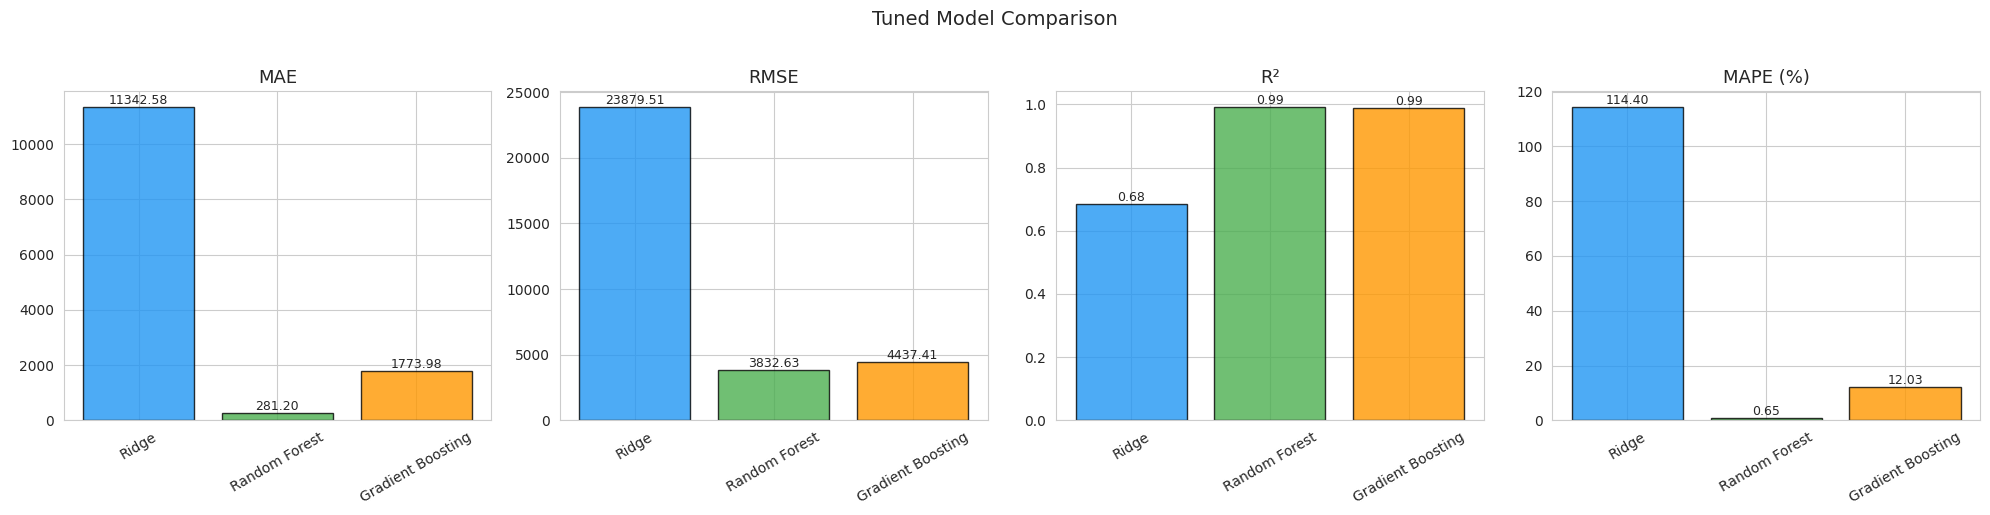

In [16]:
# --- Visual Comparison: Bar charts ---
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics_list = ['MAE', 'RMSE', 'R²', 'MAPE (%)']
model_colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, metric in enumerate(metrics_list):
    bars = axes[i].bar(tuned_df['Model'], tuned_df[metric], color=model_colors, edgecolor='black', alpha=0.8)
    axes[i].set_title(metric, fontsize=13)
    axes[i].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, tuned_df[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Tuned Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

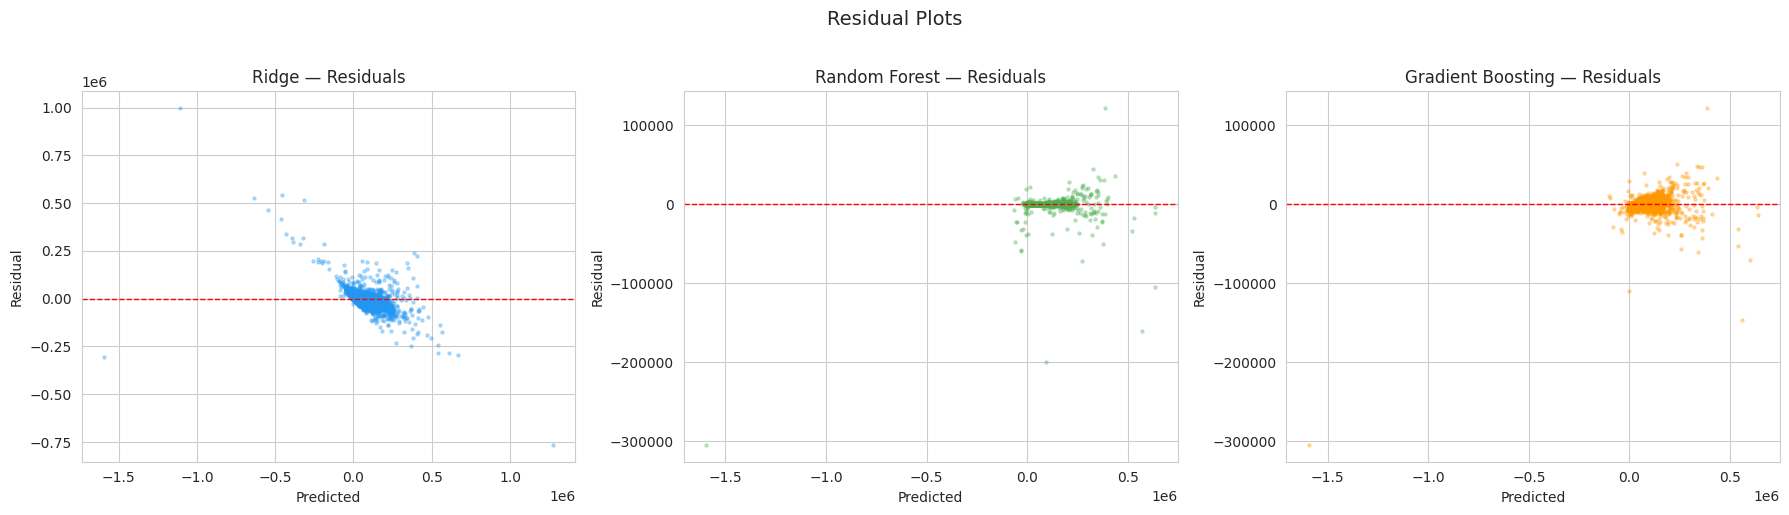

In [17]:
# --- Residual Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, y_pred) in enumerate(predictions.items()):
    residuals = y_test.values - y_pred
    axes[i].scatter(y_pred, residuals, alpha=0.3, s=5, color=model_colors[i])
    axes[i].axhline(y=0, color='red', linestyle='--', linewidth=1)
    axes[i].set_title(f'{name} — Residuals')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Residual')

plt.suptitle('Residual Plots', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()